# Le Mécanisme d'Attention dans les Transformers

Ce notebook explique pas à pas le fonctionnement du **mécanisme d'attention**, la brique fondamentale de l'architecture Transformer.


## Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Configuration globale
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 11

torch.manual_seed(42)

---

## Motivation : pourquoi l'attention ?

### Le problème des RNN (GRU, LSTM)

Les réseaux récurrents traitent les séquences **mot par mot**, en accumulant l'information dans un état caché :

```
"Le chat dort sur le canapé"

 Le → chat → dort → sur → le → canapé
 a_1   a_2    a_3   a_4   a_5   a_6
                                  ↓
                              a_6 résume TOUTE la phrase
```

**Problèmes :**
- L'état final `a_6` doit encoder **toute** la phrase → goulot d'étranglement
- Les mots du début sont "oubliés" progressivement
- Le traitement est **séquentiel** → impossible de paralléliser

### L'idée de l'attention

Au lieu de compresser toute la séquence dans un seul vecteur, l'attention permet de **regarder directement** chaque élément de la séquence :

```
Question : "Qui dort ?"  →  Regarder chaque mot de la phrase

  Le    chat   dort   sur    le   canapé
  0.02  0.85   0.08   0.02  0.01  0.02    ← poids d'attention
        ^^^^                                  ("chat" est le plus pertinent)
```

L'attention calcule une **moyenne pondérée** de tous les éléments, où les poids reflètent la **pertinence** de chaque élément par rapport à une requête.

---

## L'analogie Query / Key / Value

Le mécanisme d'attention repose sur trois concepts, inspirés des **systèmes de recherche d'information** :

```
Analogie : chercher un livre dans une bibliothèque

  Query (Q) = Ce que je cherche      → "un livre sur les chats"
  Key (K)   = L'étiquette du livre   → "animaux domestiques", "cuisine", "physique"...
  Value (V) = Le contenu du livre    → le texte réel du livre

  Étapes :
  1. Comparer ma requête (Q) avec chaque étiquette (K)
  2. Les étiquettes les plus proches de ma requête reçoivent un score élevé
  3. Récupérer le contenu (V) pondéré par ces scores
```

### En termes mathématiques

Pour chaque mot de la séquence, on calcule trois vecteurs à partir de son embedding :

```
  x_i  →  q_i = W_Q · x_i    (query : "que cherche ce mot ?")
  x_i  →  k_i = W_K · x_i    (key   : "que contient ce mot ?")
  x_i  →  v_i = W_V · x_i    (value : "quelle info transmettre ?")
```

Où `W_Q`, `W_K`, `W_V` sont des matrices de poids **apprenables**.

### Visualisation de l'analogie Q, K, V

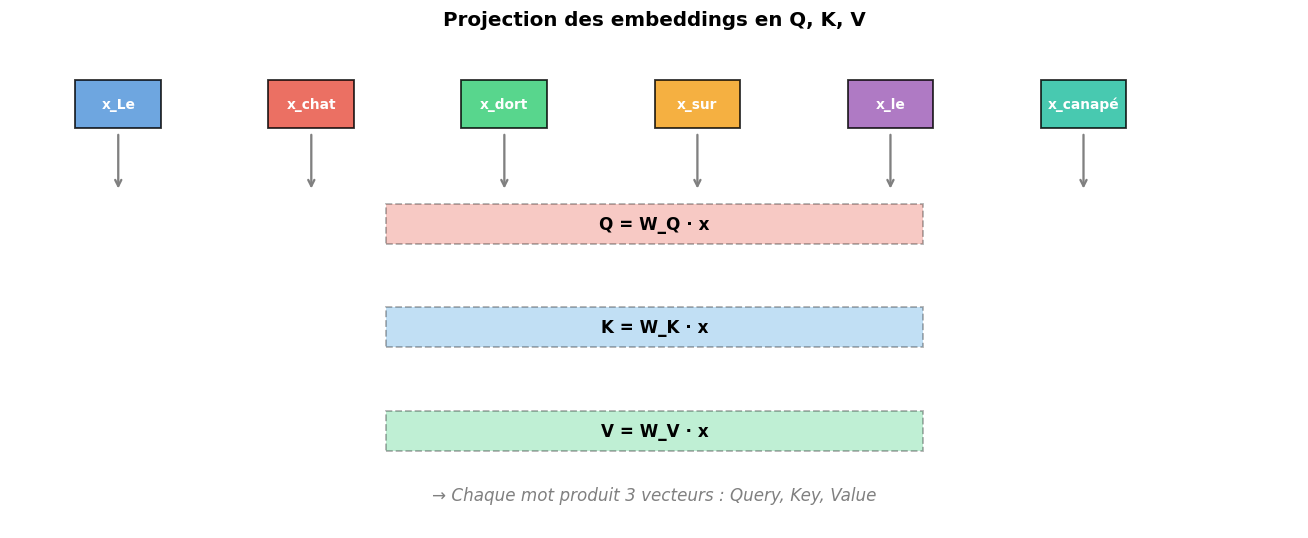

In [2]:
def visualiser_qkv():
    """Schéma illustrant la projection Q, K, V à partir des embeddings."""
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 6)
    ax.axis('off')

    mots = ["Le", "chat", "dort", "sur", "le", "canapé"]
    couleurs_mots = ['#4a90d9', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

    # Embeddings en haut
    for i, (mot, c) in enumerate(zip(mots, couleurs_mots)):
        x_pos = 1 + i * 1.8
        rect = plt.Rectangle((x_pos - 0.4, 5.0), 0.8, 0.6, facecolor=c,
                             edgecolor='black', alpha=0.8, linewidth=1.2)
        ax.add_patch(rect)
        ax.text(x_pos, 5.3, f'x_{mot}', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')


    # Flèches vers Q, K, V
    labels_proj = ['Q = W_Q · x', 'K = W_K · x', 'V = W_V · x']
    couleurs_proj = ['#e74c3c', '#3498db', '#2ecc71']
    y_proj = [3.8, 2.5, 1.2]

    for j, (lab, cp, yp) in enumerate(zip(labels_proj, couleurs_proj, y_proj)):
        # Boîte de projection
        rect = plt.Rectangle((3.5, yp - 0.25), 5.0, 0.5, facecolor=cp,
                             edgecolor='black', alpha=0.3, linewidth=1.2,
                             linestyle='--')
        ax.add_patch(rect)
        ax.text(6.0, yp, lab, ha='center', va='center', fontsize=11, fontweight='bold')

    # Flèches descendantes
    for i in range(len(mots)):
        x_pos = 1 + i * 1.8
        ax.annotate('', xy=(x_pos, 4.2), xytext=(x_pos, 4.95),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

    # Légende
    ax.text(6.0, 0.4, '→ Chaque mot produit 3 vecteurs : Query, Key, Value',
            ha='center', va='center', fontsize=11, fontstyle='italic', color='gray')

    plt.title("Projection des embeddings en Q, K, V", fontsize=13,
              fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

visualiser_qkv()

---

## Scaled Dot-Product Attention

C'est le cœur du mécanisme d'attention dans les Transformers.

### Formule

```
                              Q · K^T
  Attention(Q, K, V) = softmax(-------) · V
                              √d_k
```

### Étapes détaillées

```
  Étape 1 : Calculer les scores de similarité
            scores = Q · K^T        (produit scalaire entre queries et keys)

  Étape 2 : Mettre à l'échelle (scaling)
            scores = scores / √d_k   (d_k = dimension des keys)

  Étape 3 : Normaliser avec softmax
            poids = softmax(scores)   (somme = 1 pour chaque query)

  Étape 4 : Moyenne pondérée des values
            sortie = poids · V
```

### Pourquoi diviser par √d_k ?

Quand `d_k` est grand, les produits scalaires deviennent très grands.
La softmax est alors "saturée" (presque one-hot), ce qui bloque les gradients.
Diviser par `√d_k` maintient les scores dans une plage raisonnable.

### Visualisation : l'effet du scaling sur la softmax

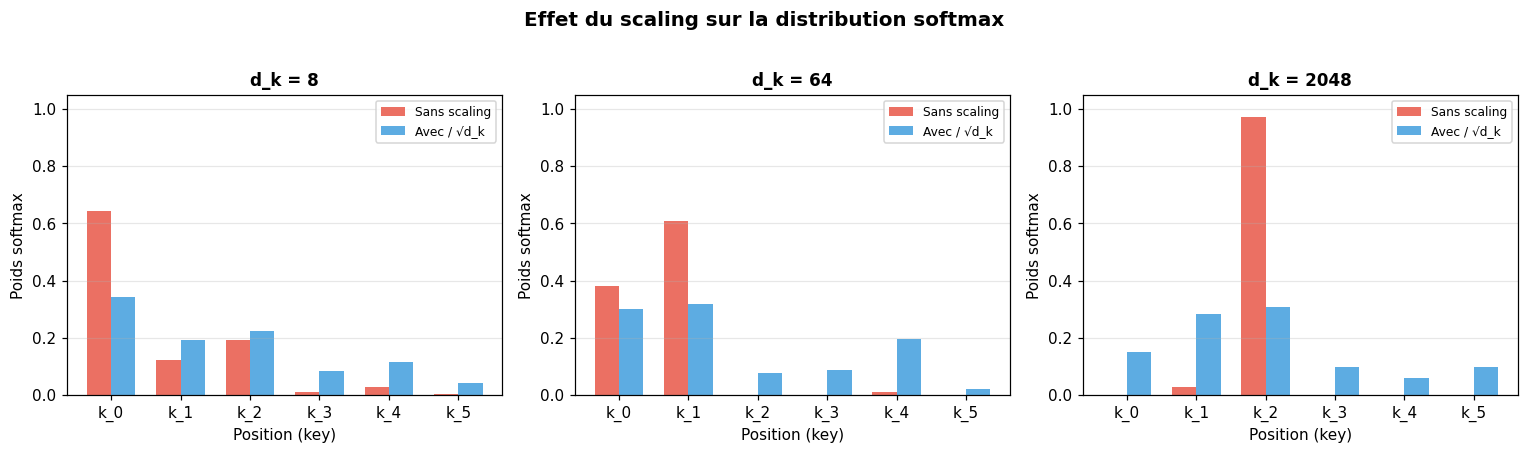

In [3]:
def visualiser_effet_scaling():
    """Montre pourquoi le scaling par √d_k est important."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    torch.manual_seed(42)

    dims = [8, 64, 2048]
    for idx, d_k in enumerate(dims):
        # Simuler des scores bruts (produit scalaire de vecteurs aléatoires)
        q = torch.randn(1, d_k)
        K = torch.randn(6, d_k)  # 6 keys

        scores_bruts = (q @ K.T).squeeze()  # sans scaling
        scores_scaled = scores_bruts / np.sqrt(d_k)  # avec scaling

        poids_bruts = F.softmax(scores_bruts, dim=0).numpy()
        poids_scaled = F.softmax(scores_scaled, dim=0).numpy()

        x = np.arange(6)
        width = 0.35

        axes[idx].bar(x - width/2, poids_bruts, width, color='#e74c3c',
                      alpha=0.8, label='Sans scaling')
        axes[idx].bar(x + width/2, poids_scaled, width, color='#3498db',
                      alpha=0.8, label='Avec / √d_k')

        axes[idx].set_title(f'd_k = {d_k}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Position (key)', fontsize=10)
        axes[idx].set_ylabel('Poids softmax', fontsize=10)
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels([f'k_{i}' for i in range(6)])
        axes[idx].legend(fontsize=8)
        axes[idx].grid(alpha=0.3, axis='y')
        axes[idx].set_ylim(0, 1.05)

    plt.suptitle('Effet du scaling sur la distribution softmax',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

visualiser_effet_scaling()

---

## Implémentation manuelle du Scaled Dot-Product Attention

On va implémenter chaque étape **à la main** pour bien comprendre les calculs.

In [4]:
def scaled_dot_product_attention_manuelle(
    Q: torch.Tensor,
    K: torch.Tensor,
    V: torch.Tensor,
    masque: torch.Tensor = None
) -> dict:
    """
    Calcule le Scaled Dot-Product Attention à la main.

    Args:
        Q : queries  — shape (seq_len_q, d_k)
        K : keys     — shape (seq_len_k, d_k)
        V : values   — shape (seq_len_k, d_v)
        masque : optionnel — shape (seq_len_q, seq_len_k), True = position masquée

    Returns:
        dict avec la sortie et les valeurs intermédiaires
    """
    d_k = K.shape[-1]

    # Étape 1 : Scores de similarité (produit scalaire)
    scores = Q @ K.T  # (seq_len_q, seq_len_k)
    print(f"Étape 1 — Scores bruts (Q · K^T) :")
    print(f"  Shape : {scores.shape}")
    print(f"  Valeurs :\n{scores.numpy().round(3)}\n")

    # Étape 2 : Scaling par √d_k
    scores_scaled = scores / np.sqrt(d_k)
    print(f"Étape 2 — Scores mis à l'échelle (/ √{d_k} = / {np.sqrt(d_k):.2f}) :")
    print(f"  Valeurs :\n{scores_scaled.numpy().round(3)}\n")

    # Étape 2b (optionnel) : Appliquer le masque
    if masque is not None:
        scores_scaled = scores_scaled.masked_fill(masque, float('-inf'))
        print(f"Étape 2b — Après masquage :")
        print(f"  Valeurs :\n{scores_scaled.numpy().round(3)}\n")

    # Étape 3 : Softmax (normalisation)
    poids_attention = F.softmax(scores_scaled, dim=-1)
    print(f"Étape 3 — Poids d'attention (softmax) :")
    print(f"  Valeurs :\n{poids_attention.numpy().round(3)}")
    print(f"  Somme par ligne : {poids_attention.sum(dim=-1).numpy().round(3)}\n")

    # Étape 4 : Moyenne pondérée des values
    sortie = poids_attention @ V  # (seq_len_q, d_v)
    print(f"Étape 4 — Sortie (poids · V) :")
    print(f"  Shape : {sortie.shape}")
    print(f"  Valeurs :\n{sortie.numpy().round(3)}")

    return {
        "sortie": sortie,
        "poids_attention": poids_attention,
        "scores": scores,
        "scores_scaled": scores_scaled
    }

In [5]:
# --- Exemple concret avec des dimensions jouets ---
# Imaginons une séquence de 4 mots, chacun projeté en dimension d_k=3

torch.manual_seed(42)

seq_len = 4  # nombre de mots
d_k = 3      # dimension des queries et keys
d_v = 3      # dimension des values

# On simule les projections Q, K, V
Q = torch.randn(seq_len, d_k)
K = torch.randn(seq_len, d_k)
V = torch.randn(seq_len, d_v)

print("=" * 60)
print("SCALED DOT-PRODUCT ATTENTION — Exemple pas à pas")
print("=" * 60)
print(f"\nDimensions : seq_len={seq_len}, d_k={d_k}, d_v={d_v}\n")

resultats = scaled_dot_product_attention_manuelle(Q, K, V)

SCALED DOT-PRODUCT ATTENTION — Exemple pas à pas

Dimensions : seq_len=4, d_k=3, d_v=3

Étape 1 — Scores bruts (Q · K^T) :
  Shape : torch.Size([4, 4])
  Valeurs :
[[-0.076  0.684 -0.037  0.375]
 [ 2.337 -1.416  0.414  0.378]
 [ 3.073  1.649 -0.588  2.092]
 [-1.407  1.625  0.488  0.652]]

Étape 2 — Scores mis à l'échelle (/ √3 = / 1.73) :
  Valeurs :
[[-0.044  0.395 -0.022  0.217]
 [ 1.35  -0.818  0.239  0.218]
 [ 1.774  0.952 -0.339  1.208]
 [-0.813  0.938  0.282  0.376]]

Étape 3 — Poids d'attention (softmax) :
  Valeurs :
[[0.205 0.318 0.21  0.266]
 [0.566 0.065 0.187 0.183]
 [0.47  0.207 0.057 0.267]
 [0.077 0.442 0.229 0.252]]
  Somme par ligne : [1. 1. 1. 1.]

Étape 4 — Sortie (poids · V) :
  Shape : torch.Size([4, 3])
  Valeurs :
[[ 0.21  -0.122  0.066]
 [ 0.3   -0.021  0.193]
 [ 0.313 -0.213  0.125]
 [ 0.132 -0.106  0.079]]


### Visualisation des poids d'attention

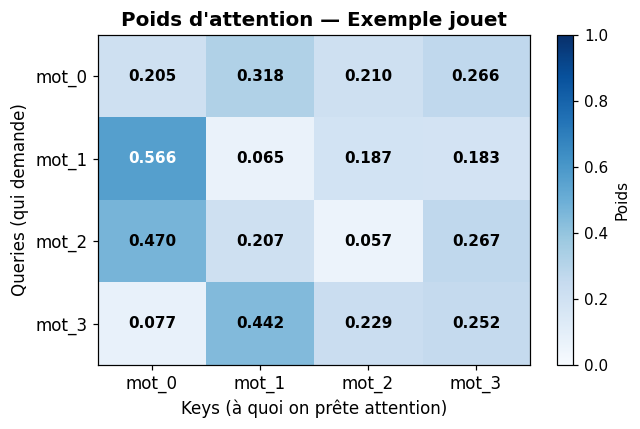

In [6]:
def visualiser_attention(poids: torch.Tensor, mots_query: list = None,
                         mots_key: list = None, titre: str = "Poids d'attention"):
    """
    Affiche une heatmap des poids d'attention.

    Args:
        poids      : tensor de shape (seq_len_q, seq_len_k)
        mots_query : labels pour l'axe Y (queries)
        mots_key   : labels pour l'axe X (keys)
        titre      : titre du graphique
    """
    data = poids.detach().numpy()
    seq_q, seq_k = data.shape

    if mots_query is None:
        mots_query = [f'Q_{i}' for i in range(seq_q)]
    if mots_key is None:
        mots_key = [f'K_{i}' for i in range(seq_k)]

    fig, ax = plt.subplots(figsize=(max(6, seq_k * 1.2), max(4, seq_q * 0.8)))
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=1, aspect='auto')

    # Annotations
    for i in range(seq_q):
        for j in range(seq_k):
            couleur = 'white' if data[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{data[i, j]:.3f}', ha='center', va='center',
                    fontsize=10, color=couleur, fontweight='bold')

    ax.set_xticks(range(seq_k))
    ax.set_xticklabels(mots_key, fontsize=11)
    ax.set_yticks(range(seq_q))
    ax.set_yticklabels(mots_query, fontsize=11)
    ax.set_xlabel('Keys (à quoi on prête attention)', fontsize=11)
    ax.set_ylabel('Queries (qui demande)', fontsize=11)
    ax.set_title(titre, fontsize=13, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Poids')
    plt.tight_layout()
    plt.show()


visualiser_attention(
    resultats["poids_attention"],
    mots_query=["mot_0", "mot_1", "mot_2", "mot_3"],
    mots_key=["mot_0", "mot_1", "mot_2", "mot_3"],
    titre="Poids d'attention — Exemple jouet"
)

---

## Self-Attention : quand Q, K, V viennent de la même séquence

Dans le **self-attention**, chaque mot de la phrase cherche de l'information dans **tous les autres mots** de la même phrase :

```
Phrase : "Le chat mange le poisson"

Pour le mot "mange" (query) :
  - Q_mange compare avec K_Le, K_chat, K_mange, K_le, K_poisson
  - Résultat probable : forte attention sur "chat" (sujet) et "poisson" (objet)

Chaque mot X_i produit :
  Q_i = W_Q · X_i   ← "que cherche ce mot ?"
  K_i = W_K · X_i   ← "que contient ce mot ?"
  V_i = W_V · X_i   ← "quelle info transmettre ?"
```

Le self-attention permet à chaque mot de **contextualiser** sa représentation en fonction de tous les autres mots.

### Implémentation du Self-Attention

In [7]:
class SelfAttentionManuelle:
    """
    Self-Attention implémenté manuellement.

    Chaque token de la séquence est projeté en Q, K, V
    via des matrices de poids apprenables.

    Paramètres :
        d_model : dimension des embeddings d'entrée
        d_k     : dimension des queries et keys
        d_v     : dimension des values
    """

    def __init__(self, d_model: int, d_k: int, d_v: int):
        self.d_k = d_k
        self.d_v = d_v

        # Matrices de projection apprenables
        self.W_Q = torch.randn(d_model, d_k) * 0.1
        self.W_K = torch.randn(d_model, d_k) * 0.1
        self.W_V = torch.randn(d_model, d_v) * 0.1

    def forward(self, X: torch.Tensor) -> dict:
        """
        Calcule le self-attention.

        Args:
            X : embeddings d'entrée — shape (seq_len, d_model)

        Returns:
            dict avec la sortie et les valeurs intermédiaires
        """
        # Projections
        Q = X @ self.W_Q  # (seq_len, d_k)
        K = X @ self.W_K  # (seq_len, d_k)
        V = X @ self.W_V  # (seq_len, d_v)

        # Scores de similarité
        scores = Q @ K.T / np.sqrt(self.d_k)  # (seq_len, seq_len)

        # Poids d'attention
        poids = F.softmax(scores, dim=-1)  # (seq_len, seq_len)

        # Sortie : moyenne pondérée des values
        sortie = poids @ V  # (seq_len, d_v)

        return {
            "sortie": sortie,
            "poids": poids,
            "Q": Q, "K": K, "V": V,
            "scores": scores
        }


# --- Exemple avec une phrase ---
# Simulons des embeddings pour la phrase "Le chat mange le poisson"
torch.manual_seed(42)

mots = ["Le", "chat", "mange", "le", "poisson"]
seq_len = len(mots)
d_model = 8   # dimension des embeddings
d_k = 4       # dimension des queries/keys
d_v = 4       # dimension des values

# Embeddings simulés (en pratique, appris)
X = torch.randn(seq_len, d_model)

attention = SelfAttentionManuelle(d_model, d_k, d_v)
res = attention.forward(X)

print(f"Phrase : {' '.join(mots)}")
print(f"\nDimensions :")
print(f"  Entrée X : {X.shape}")
print(f"  Q, K     : {res['Q'].shape}")
print(f"  V        : {res['V'].shape}")
print(f"  Poids    : {res['poids'].shape}")
print(f"  Sortie   : {res['sortie'].shape}")

Phrase : Le chat mange le poisson

Dimensions :
  Entrée X : torch.Size([5, 8])
  Q, K     : torch.Size([5, 4])
  V        : torch.Size([5, 4])
  Poids    : torch.Size([5, 5])
  Sortie   : torch.Size([5, 4])


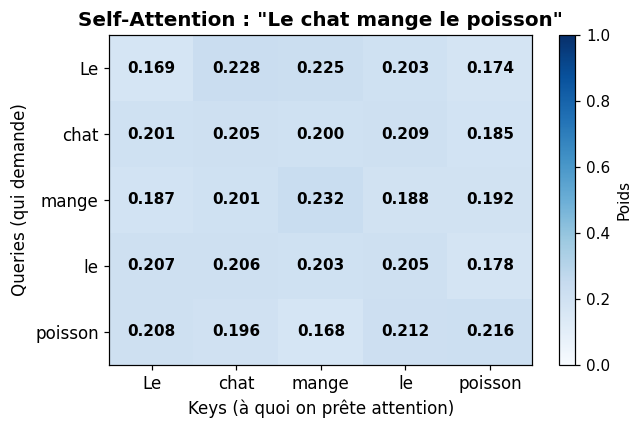

In [8]:
# Visualisation des poids d'attention pour cette phrase
visualiser_attention(
    res["poids"],
    mots_query=mots,
    mots_key=mots,
    titre='Self-Attention : "Le chat mange le poisson"'
)

---

## Le masque causal (pour les décodeurs)

Dans un **décodeur** (ex. GPT), chaque mot ne doit voir que les mots **précédents**, pas les mots futurs. On utilise un **masque causal** :

```
Phrase : "Le chat mange le poisson"

Sans masque (encodeur) :        Avec masque causal (décodeur) :
           Le ch ma le po                  Le ch ma le po
    Le   [ ✓  ✓  ✓  ✓  ✓ ]        Le   [ ✓  ✗  ✗  ✗  ✗ ]
    chat [ ✓  ✓  ✓  ✓  ✓ ]        chat [ ✓  ✓  ✗  ✗  ✗ ]
    mange[ ✓  ✓  ✓  ✓  ✓ ]        mange[ ✓  ✓  ✓  ✗  ✗ ]
    le   [ ✓  ✓  ✓  ✓  ✓ ]        le   [ ✓  ✓  ✓  ✓  ✗ ]
    poisson[ ✓  ✓  ✓  ✓  ✓ ]      poisson[ ✓  ✓  ✓  ✓  ✓ ]

Les ✗ sont remplacés par -∞ avant le softmax → poids = 0
```

In [9]:
def creer_masque_causal(seq_len: int) -> torch.Tensor:
    """
    Crée un masque causal triangulaire supérieur.
    True = position masquée (ne peut pas voir le futur).

    Args:
        seq_len : longueur de la séquence

    Returns:
        masque : tensor booléen de shape (seq_len, seq_len)
    """
    masque = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    return masque


# Visualisons le masque
masque = creer_masque_causal(5)
print("Masque causal (True = masqué) :")
print(masque.int().numpy())

# Appliquer le self-attention avec masque
print("\n" + "=" * 60)
print("SELF-ATTENTION AVEC MASQUE CAUSAL")
print("=" * 60 + "\n")

res_masque = scaled_dot_product_attention_manuelle(
    res["Q"], res["K"], res["V"], masque=masque
)

Masque causal (True = masqué) :
[[0 1 1 1 1]
 [0 0 1 1 1]
 [0 0 0 1 1]
 [0 0 0 0 1]
 [0 0 0 0 0]]

SELF-ATTENTION AVEC MASQUE CAUSAL

Étape 1 — Scores bruts (Q · K^T) :
  Shape : torch.Size([5, 5])
  Valeurs :
[[-0.385  0.216  0.189 -0.022 -0.326]
 [-0.004  0.032 -0.015  0.074 -0.173]
 [-0.135  0.008  0.292 -0.123 -0.083]
 [ 0.064  0.054  0.02   0.045 -0.244]
 [ 0.093 -0.024 -0.328  0.13   0.169]]

Étape 2 — Scores mis à l'échelle (/ √4 = / 2.00) :
  Valeurs :
[[-0.192  0.108  0.095 -0.011 -0.163]
 [-0.002  0.016 -0.008  0.037 -0.086]
 [-0.068  0.004  0.146 -0.062 -0.041]
 [ 0.032  0.027  0.01   0.022 -0.122]
 [ 0.047 -0.012 -0.164  0.065  0.085]]

Étape 2b — Après masquage :
  Valeurs :
[[-0.192   -inf   -inf   -inf   -inf]
 [-0.002  0.016   -inf   -inf   -inf]
 [-0.068  0.004  0.146   -inf   -inf]
 [ 0.032  0.027  0.01   0.022   -inf]
 [ 0.047 -0.012 -0.164  0.065  0.085]]

Étape 3 — Poids d'attention (softmax) :
  Valeurs :
[[1.    0.    0.    0.    0.   ]
 [0.496 0.504 0.    0.    

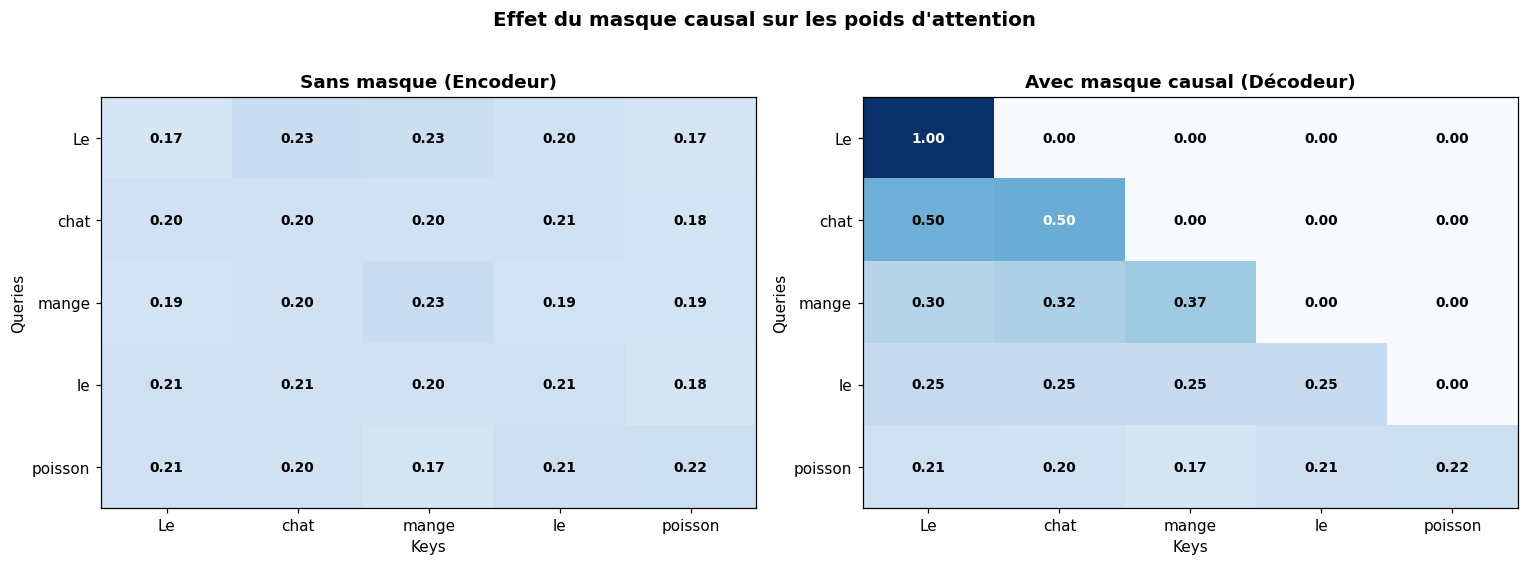

In [10]:
# Comparaison côte à côte : sans masque vs avec masque
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, poids, titre in [
    (axes[0], res["poids"], "Sans masque (Encodeur)"),
    (axes[1], res_masque["poids_attention"], "Avec masque causal (Décodeur)")
]:
    data = poids.detach().numpy()
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    for i in range(len(mots)):
        for j in range(len(mots)):
            couleur = 'white' if data[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, color=couleur, fontweight='bold')
    ax.set_xticks(range(len(mots)))
    ax.set_xticklabels(mots, fontsize=10)
    ax.set_yticks(range(len(mots)))
    ax.set_yticklabels(mots, fontsize=10)
    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Keys', fontsize=10)
    ax.set_ylabel('Queries', fontsize=10)

plt.suptitle('Effet du masque causal sur les poids d\'attention',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Multi-Head Attention

Plutôt qu'une seule attention, le Transformer utilise **plusieurs têtes d'attention en parallèle**. Chaque tête apprend à se concentrer sur un **aspect différent** de la séquence.

```
Analogie : lire un texte avec plusieurs "lunettes"

  Tête 1 : se concentre sur la syntaxe      (sujet → verbe)
  Tête 2 : se concentre sur la sémantique    (mot → synonyme)
  Tête 3 : se concentre sur la proximité     (mots voisins)
  Tête 4 : se concentre sur les références   (pronom → nom)
```

### Formule

```
  MultiHead(Q, K, V) = Concat(tête_1, ..., tête_h) · W_O

  où tête_i = Attention(Q · W_Q^i, K · W_K^i, V · W_V^i)
```

### Dimensions

```
  d_model = 512          (dimension du modèle)
  h = 8                  (nombre de têtes)
  d_k = d_v = d_model / h = 64   (dimension par tête)

  Chaque tête travaille dans un sous-espace de dimension 64
  Les h têtes sont concaténées → dimension 8 × 64 = 512 = d_model
  W_O projette le résultat dans l'espace de sortie (512 → 512)
```

In [11]:
class MultiHeadAttentionManuelle(nn.Module):
    """
    Multi-Head Attention implémenté manuellement.

    Paramètres :
        d_model  : dimension du modèle (embeddings)
        nb_tetes : nombre de têtes d'attention
    """

    def __init__(self, d_model: int, nb_tetes: int):
        super().__init__()
        assert d_model % nb_tetes == 0, "d_model doit être divisible par nb_tetes"

        self.d_model = d_model
        self.nb_tetes = nb_tetes
        self.d_k = d_model // nb_tetes  # dimension par tête

        # Projections linéaires pour Q, K, V
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)

        # Projection de sortie
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, X: torch.Tensor, masque: torch.Tensor = None) -> dict:
        """
        Args:
            X      : (batch_size, seq_len, d_model)
            masque : optionnel — (seq_len, seq_len)

        Returns:
            dict avec sortie et poids d'attention par tête
        """
        batch_size, seq_len, _ = X.shape

        # 1. Projections linéaires
        Q = self.W_Q(X)  # (batch, seq_len, d_model)
        K = self.W_K(X)
        V = self.W_V(X)

        # 2. Découper en nb_tetes têtes
        #    (batch, seq_len, d_model) → (batch, nb_tetes, seq_len, d_k)
        Q = Q.view(batch_size, seq_len, self.nb_tetes, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.nb_tetes, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.nb_tetes, self.d_k).transpose(1, 2)

        # 3. Scaled Dot-Product Attention pour chaque tête
        scores = Q @ K.transpose(-2, -1) / np.sqrt(self.d_k)
        # scores : (batch, nb_tetes, seq_len, seq_len)

        if masque is not None:
            scores = scores.masked_fill(masque.unsqueeze(0).unsqueeze(0), float('-inf'))

        poids = F.softmax(scores, dim=-1)
        # poids : (batch, nb_tetes, seq_len, seq_len)

        contexte = poids @ V  # (batch, nb_tetes, seq_len, d_k)

        # 4. Concaténer les têtes
        #    (batch, nb_tetes, seq_len, d_k) → (batch, seq_len, d_model)
        contexte = contexte.transpose(1, 2).contiguous().view(
            batch_size, seq_len, self.d_model
        )

        # 5. Projection de sortie
        sortie = self.W_O(contexte)  # (batch, seq_len, d_model)

        return {
            "sortie": sortie,
            "poids_par_tete": poids  # (batch, nb_tetes, seq_len, seq_len)
        }


# --- Exemple ---
torch.manual_seed(42)

d_model = 16
nb_tetes = 4
seq_len = 5
batch_size = 1

mha = MultiHeadAttentionManuelle(d_model, nb_tetes)
X_mha = torch.randn(batch_size, seq_len, d_model)

res_mha = mha(X_mha)

print(f"Multi-Head Attention : {nb_tetes} têtes, d_model={d_model}")
print(f"  d_k par tête : {d_model // nb_tetes}")
print(f"  Entrée       : {X_mha.shape}")
print(f"  Sortie       : {res_mha['sortie'].shape}")
print(f"  Poids        : {res_mha['poids_par_tete'].shape}")
print(f"\nParamètres : {sum(p.numel() for p in mha.parameters())}")

Multi-Head Attention : 4 têtes, d_model=16
  d_k par tête : 4
  Entrée       : torch.Size([1, 5, 16])
  Sortie       : torch.Size([1, 5, 16])
  Poids        : torch.Size([1, 4, 5, 5])

Paramètres : 1024


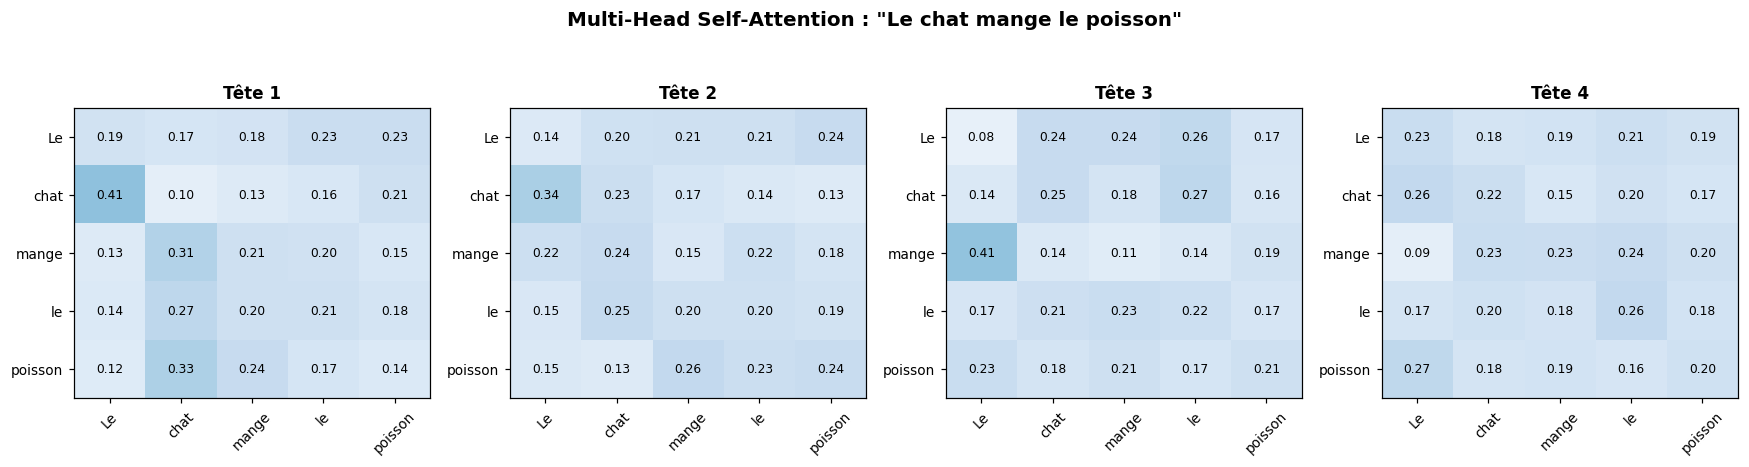

In [12]:
def visualiser_multi_tetes(poids_par_tete: torch.Tensor, mots: list,
                           titre: str = "Multi-Head Attention"):
    """
    Affiche les poids d'attention pour chaque tête côte à côte.

    Args:
        poids_par_tete : (batch, nb_tetes, seq_len, seq_len)
        mots           : liste des mots de la séquence
    """
    poids = poids_par_tete[0].detach().numpy()  # (nb_tetes, seq_len, seq_len)
    nb_tetes = poids.shape[0]

    fig, axes = plt.subplots(1, nb_tetes, figsize=(4 * nb_tetes, 4))
    if nb_tetes == 1:
        axes = [axes]

    for h in range(nb_tetes):
        ax = axes[h]
        data = poids[h]
        im = ax.imshow(data, cmap='Blues', vmin=0, vmax=1, aspect='auto')

        for i in range(len(mots)):
            for j in range(len(mots)):
                couleur = 'white' if data[i, j] > 0.5 else 'black'
                ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center',
                        fontsize=8, color=couleur)

        ax.set_xticks(range(len(mots)))
        ax.set_xticklabels(mots, fontsize=9, rotation=45)
        ax.set_yticks(range(len(mots)))
        ax.set_yticklabels(mots, fontsize=9)
        ax.set_title(f'Tête {h + 1}', fontsize=11, fontweight='bold')

    plt.suptitle(titre, fontsize=13, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


visualiser_multi_tetes(
    res_mha["poids_par_tete"],
    mots=mots,
    titre='Multi-Head Self-Attention : "Le chat mange le poisson"'
)

---

## Utilisation de `torch.nn.MultiheadAttention`

PyTorch fournit une implémentation optimisée du Multi-Head Attention.

### Paramètres principaux

```python
nn.MultiheadAttention(
    embed_dim,     # d_model : dimension des embeddings
    num_heads,     # h : nombre de têtes
    dropout=0.0,   # dropout sur les poids d'attention
    batch_first=True  # si True : entrée (batch, seq, d_model)
)
```

### Forme des tenseurs

```
Entrées Q, K, V : (batch_size, seq_len, d_model)   ← si batch_first=True
Sortie          : (batch_size, seq_len, d_model)
Poids attention : (batch_size, seq_len, seq_len)
```

In [13]:
# --- Configuration ---
d_model = 32
nb_tetes = 4
seq_len = 6
batch_size = 2

# --- Création du module PyTorch ---
mha_pytorch = nn.MultiheadAttention(
    embed_dim=d_model,
    num_heads=nb_tetes,
    batch_first=True
)

print("Architecture du MultiheadAttention :")
print(mha_pytorch)
print()

nb_params = sum(p.numel() for p in mha_pytorch.parameters())
print(f"Nombre total de paramètres : {nb_params}")
print(f"  W_Q, W_K, W_V : 3 × {d_model} × {d_model} = {3 * d_model * d_model}")
print(f"  W_O           : {d_model} × {d_model} = {d_model * d_model}")
print(f"  + biais")

# --- Passage d'un batch (self-attention : Q=K=V=X) ---
torch.manual_seed(42)
X = torch.randn(batch_size, seq_len, d_model)

sortie, poids = mha_pytorch(X, X, X, need_weights=True)

print(f"\nForme de l'entrée X  : {X.shape}")
print(f"Forme de la sortie   : {sortie.shape}")
print(f"Forme des poids      : {poids.shape}")

Architecture du MultiheadAttention :
MultiheadAttention(
  (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
)

Nombre total de paramètres : 4224
  W_Q, W_K, W_V : 3 × 32 × 32 = 3072
  W_O           : 32 × 32 = 1024
  + biais

Forme de l'entrée X  : torch.Size([2, 6, 32])
Forme de la sortie   : torch.Size([2, 6, 32])
Forme des poids      : torch.Size([2, 6, 6])


In [14]:
# --- Self-attention avec masque causal ---
masque_causal = torch.nn.Transformer.generate_square_subsequent_mask(seq_len)

sortie_masquee, poids_masques = mha_pytorch(
    X, X, X,
    attn_mask=masque_causal,
    need_weights=True
)

print("Masque causal (valeurs -inf pour positions futures) :")
print(masque_causal.numpy().round(1))
print(f"\nPoids d'attention masqués (batch 0) :")
print(poids_masques[0].detach().numpy().round(3))

Masque causal (valeurs -inf pour positions futures) :
[[  0. -inf -inf -inf -inf -inf]
 [  0.   0. -inf -inf -inf -inf]
 [  0.   0.   0. -inf -inf -inf]
 [  0.   0.   0.   0. -inf -inf]
 [  0.   0.   0.   0.   0. -inf]
 [  0.   0.   0.   0.   0.   0.]]

Poids d'attention masqués (batch 0) :
[[1.    0.    0.    0.    0.    0.   ]
 [0.633 0.367 0.    0.    0.    0.   ]
 [0.332 0.322 0.346 0.    0.    0.   ]
 [0.258 0.26  0.213 0.269 0.    0.   ]
 [0.205 0.258 0.142 0.277 0.118 0.   ]
 [0.104 0.162 0.172 0.2   0.192 0.17 ]]


---

## Application : visualiser l'attention sur de vraies phrases

On va créer un mini-vocabulaire et observer comment le self-attention apprend à relier les mots entre eux.

In [15]:
def encodage_positionnel(seq_len_max: int, d_model: int) -> torch.Tensor:
    """
    Calcule l'encodage positionnel sinusoïdal (Vaswani et al. 2017).

    PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))

    Returns:
        Tensor de shape (seq_len_max, d_model)
    """
    pe = torch.zeros(seq_len_max, d_model)
    position = torch.arange(0, seq_len_max).unsqueeze(1).float()
    div_term = torch.exp(
        torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


class MiniTransformerAttention(nn.Module):
    """
    Modèle minimal avec :
      1. Embedding des mots
      2. Encodage positionnel
      3. Une couche de Multi-Head Self-Attention
      4. Projection de sortie (classification du mot suivant)
    """

    def __init__(self, taille_vocab: int, d_model: int, nb_tetes: int,
                 seq_len_max: int):
        super().__init__()
        self.d_model = d_model
        self.nb_tetes = nb_tetes

        # Embedding des tokens
        self.embedding = nn.Embedding(taille_vocab, d_model)

        # Encodage positionnel (fixe, pas appris)
        self.register_buffer('pe', encodage_positionnel(seq_len_max, d_model))

        # Self-Attention
        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nb_tetes,
            batch_first=True
        )

        # Norme de couche (Layer Norm)
        self.norm = nn.LayerNorm(d_model)

        # Projection de sortie
        self.fc_sortie = nn.Linear(d_model, taille_vocab)

    def forward(self, tokens: torch.Tensor,
                moyenne_tetes: bool = True) -> dict:
        """
        Args:
            tokens        : (batch_size, seq_len) — indices des mots
            moyenne_tetes : si True, retourne la moyenne des poids sur toutes
                            les têtes (shape seq×seq) ; si False, retourne
                            les poids par tête (shape nb_tetes×seq×seq).

        Returns:
            dict avec logits et poids d'attention
        """
        seq_len = tokens.shape[1]

        # 1. Embedding + positional encoding
        x = self.embedding(tokens) * np.sqrt(self.d_model)  # scaling standard
        x = x + self.pe[:seq_len]

        # 2. Self-Attention avec masque causal
        masque = torch.nn.Transformer.generate_square_subsequent_mask(seq_len)
        masque = masque.to(tokens.device)

        attn_sortie, poids_attn = self.attention(
            x, x, x,
            attn_mask=masque,
            need_weights=True,
            average_attn_weights=moyenne_tetes   # ← nouveau paramètre
        )

        # 3. Connexion résiduelle + LayerNorm
        x = self.norm(x + attn_sortie)

        # 4. Projection vers le vocabulaire
        logits = self.fc_sortie(x)  # (batch, seq_len, taille_vocab)

        return {"logits": logits, "poids_attention": poids_attn}


# --- Construction d'un mini-vocabulaire ---
vocabulaire = {
    "<pad>": 0, "le": 1, "chat": 2, "mange": 3, "poisson": 4,
    "dort": 5, "sur": 6, "canapé": 7, "un": 8, "la": 9,
    "souris": 10, "regarde": 11, "petit": 12, "gros": 13
}
idx_vers_mot = {v: k for k, v in vocabulaire.items()}

# Phrases d'entraînement — le corpus est enrichi pour renforcer les
# associations "gros → chat" et "mange → poisson"
phrases = [
    [1, 2, 3, 1, 4],        # le chat mange le poisson
    [1, 2, 5, 6, 1, 7],     # le chat dort sur le canapé
    [9, 10, 3, 1, 4],       # la souris mange le poisson
    [1, 12, 2, 5],          # le petit chat dort
    [1, 13, 2, 3, 9, 10],   # le gros chat mange la souris
    [1, 2, 11, 9, 10],      # le chat regarde la souris
    # Nouvelles phrases renforçant les associations clés
    [1, 13, 2, 3, 1, 4],    # le gros chat mange le poisson
    [1, 13, 2, 5],          # le gros chat dort
    [1, 2, 3, 9, 10],       # le chat mange la souris
    [9, 13, 10, 3, 1, 4],   # la gros souris mange le poisson
]

print(f"Vocabulaire : {len(vocabulaire)} mots")
print("Phrases d'entraînement :")
for p in phrases:
    print(f"  {' '.join(idx_vers_mot[i] for i in p)}")

Vocabulaire : 14 mots
Phrases d'entraînement :
  le chat mange le poisson
  le chat dort sur le canapé
  la souris mange le poisson
  le petit chat dort
  le gros chat mange la souris
  le chat regarde la souris
  le gros chat mange le poisson
  le gros chat dort
  le chat mange la souris
  la gros souris mange le poisson


Epoch 100/600 — Perte : 0.6774
Epoch 200/600 — Perte : 0.5170
Epoch 300/600 — Perte : 0.4910
Epoch 400/600 — Perte : 0.4817
Epoch 500/600 — Perte : 0.4769
Epoch 600/600 — Perte : 0.4721
Entraînement terminé.


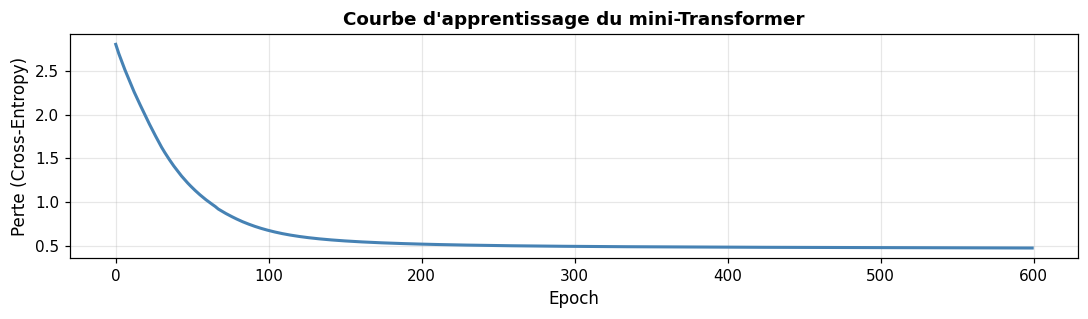

In [16]:
# --- Entraînement du mini-modèle ---
torch.manual_seed(42)

modele = MiniTransformerAttention(
    taille_vocab=len(vocabulaire),
    d_model=32,
    nb_tetes=4,
    seq_len_max=20
)

critere = nn.CrossEntropyLoss(ignore_index=0)  # ignore le padding
optimiseur = torch.optim.Adam(modele.parameters(), lr=1e-3)

# Padding des phrases à la même longueur
max_len = max(len(p) for p in phrases)
phrases_padded = [p + [0] * (max_len - len(p)) for p in phrases]
donnees = torch.tensor(phrases_padded)  # (nb_phrases, max_len)

nb_epochs = 600
historique = []

for epoch in range(nb_epochs):
    modele.train()

    # Entrée = tous les mots sauf le dernier
    # Cible  = tous les mots sauf le premier (décalage)
    entree = donnees[:, :-1]
    cible  = donnees[:, 1:]

    optimiseur.zero_grad()
    res = modele(entree)
    logits = res["logits"]  # (batch, seq_len-1, vocab)

    perte = critere(logits.reshape(-1, len(vocabulaire)), cible.reshape(-1))
    perte.backward()
    optimiseur.step()

    historique.append(perte.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:3d}/{nb_epochs} — Perte : {perte.item():.4f}")

print("Entraînement terminé.")

# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(historique, color='steelblue', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Perte (Cross-Entropy)', fontsize=11)
ax.set_title("Courbe d'apprentissage du mini-Transformer",
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()